# $\color{#6aa2eb}{\textbf{Linear regression}}$

In [1]:
import pandas as pd
import seaborn as sn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
data = sn.load_dataset('penguins')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---

## $\color{#76ddff}{\textbf{Exercise 1 - features}}$

Let's consider the relationship between bill length, bill depth, and flipper length as $X$ and body mass $y$ for Adelie penguins. Train `sklearn.linear_model.LinearRegression` models using 1, 2, and 3 features. Calculate the SSR.

Compare the SSR values and the obtained coefficients for the models trained on a different number of features. Plot the obtained SSR values as a function of the number of features used. Which single feature best predicts the penguin's body mass? Are the features correlated with each other?

In [3]:
def SSR(w0, w1, x, y):
  ypred = np.dot(x,w0) + w1
  return np.dot((ypred - y).T, (ypred - y))

In [4]:
data_adelie = data[data['species'] == 'Adelie'].dropna()
SSRs = []
features_lens = []
feature_combos = [['flipper_length_mm'], ['bill_length_mm'], ['bill_depth_mm'], ['flipper_length_mm', 'bill_length_mm'], ['flipper_length_mm', 'bill_depth_mm'], ['bill_length_mm', 'bill_depth_mm'], ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]

for features in feature_combos:
  features_len = len(features)

  if features_len == 1:
    X, y = np.array(data_adelie[features]).reshape([-1,1]), np.array(data_adelie['body_mass_g'])
  else:
    X, y = np.array(data_adelie[features]), np.array(data_adelie['body_mass_g'])

  lr = LinearRegression()
  lr.fit(X, y)
  SSRs.append(SSR(lr.coef_, lr.intercept_, X, y))
  features_lens.append(features_len)

  print(f"features length: {features_len}, w0: {lr.coef_}, w1: {lr.intercept_}, SSR: {SSRs[-1]}")

features length: 1, w0: [32.68891409], w1: -2508.087742892713, SSR: 23907870.688678645
features length: 1, w0: [93.74912757], w1: 66.45082339411329, SSR: 21463511.945386246
features length: 1, w0: [218.2095456], w1: -297.38294374151246, SSR: 20233086.97905498
features length: 2, w0: [22.45009579 75.47745747], w1: -3491.995075203827, SSR: 18698261.23056339
features length: 2, w0: [ 22.14576452 181.38370081], w1: -3831.700092887271, SSR: 17500712.542771954
features length: 2, w0: [ 64.84783195 163.57670612], w1: -1812.6704691367063, SSR: 16553704.93257517
features length: 3, w0: [ 16.91480265  54.51241616 144.15670112], w1: -4270.655009599772, SSR: 15053151.773694135


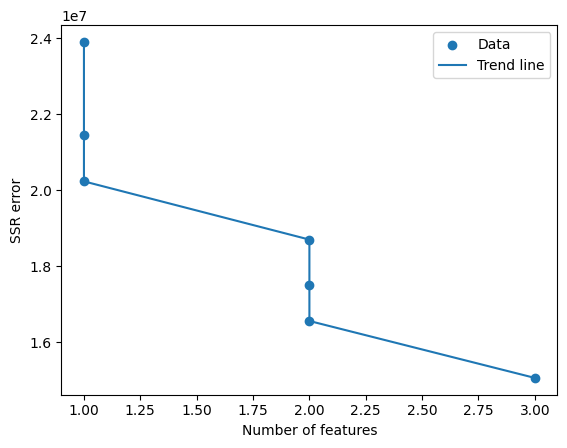

In [5]:
plt.scatter(features_lens, SSRs, label = 'Data')
plt.plot(features_lens, SSRs, label = 'Trend line')
plt.xlabel('Number of features')
plt.ylabel('SSR error')
plt.legend()
plt.show()

In [6]:
print(f"The best single predictor of an Adelie penguin's body mass is {feature_combos[np.argmin(SSRs[:3])][0]}.")

The best single predictor of an Adelie penguin's body mass is bill_depth_mm.


In [7]:
from scipy.stats import spearmanr

print('flipper_length_mm - bill_length_mm: ', spearmanr(data_adelie['flipper_length_mm'], data_adelie['bill_length_mm']))
print('flipper_length_mm - bill_depth_mm: ', spearmanr(data_adelie['flipper_length_mm'], data_adelie['bill_depth_mm']))
print('bill_depth_mm - bill_length_mm: ', spearmanr(data_adelie['bill_depth_mm'], data_adelie['bill_length_mm']))

flipper_length_mm - bill_length_mm:  SignificanceResult(statistic=np.float64(0.3479158813111195), pvalue=np.float64(1.685301728097268e-05))
flipper_length_mm - bill_depth_mm:  SignificanceResult(statistic=np.float64(0.32955905080458153), pvalue=np.float64(4.8671212323948756e-05))
bill_depth_mm - bill_length_mm:  SignificanceResult(statistic=np.float64(0.3554567936479738), pvalue=np.float64(1.0689183796192128e-05))


Conclusion: Features are not strongly correlated. The greater the number of features, the higher the $R^2$ score.

## $\color{#76ddff}{\textbf{Exercise 2 - collinearity}}$

Given:

In [8]:
x1 = np.random.random(100)
x2 = np.random.random(100)

In [9]:
r1 = np.random.random(100)
r2 = np.random.random()*r1

In [10]:
y1 = 5*x1 + 3*x2
y2 = 5*r1 + 3*r2

Fit the sklearn.linear_model.LinearRegression models and compare the coefficients obtained in both cases. Are they the same? Why? Compare the r2_score of both models - which one is better? Which assumption of linear regression might be violated?

In [11]:
from sklearn.metrics import r2_score

In [12]:
X_case1 = np.column_stack((x1, x2))
lr_case1 = LinearRegression()
lr_case1.fit(X_case1, y1)

y_pred1 = lr_case1.predict(X_case1)
r2_case1 = r2_score(y1, y_pred1)

print('Coefficients (w) ', lr_case1.coef_, ' intercept (w1)  ', str(lr_case1.intercept_))
print('R2 score: ', r2_case1)

Coefficients (w)  [5. 3.]  intercept (w1)   1.7763568394002505e-15
R2 score:  1.0


In [13]:
X_case2 = np.column_stack((r1, r2))
lr_case2 = LinearRegression()
lr_case2.fit(X_case2, y2)

y_pred2 = lr_case2.predict(X_case2)
r2_case2 = r2_score(y2, y_pred2)

print('Coefficients (w) ', lr_case2.coef_, ' intercept (w1)  ', str(lr_case2.intercept_))
print('R2 score: ', r2_case2)

Coefficients (w)  [4.24087722 3.8386634 ]  intercept (w1)   -4.440892098500626e-16
R2 score:  1.0


Conclusion: Both models have $R^2 = 1$, which suggests that they are equally good, but only in case 1 do we obtain the expected slope and coefficient values: $3$ and $5$. Collinearity has worsened the interpretability of the model's coefficients.


Mathematically, this can be explained as follows: having $x_1$ and $x_2$ and a dependent variable in the form $y = a_1 x_1 + a_2 x_2$, we assume that $x_2 = c x_1$, meaning that $x_2$ is linearly dependent on $x_1$. Then the dependent variable becomes $y = a_1 x_1 + a_2 c x_1 = (a_1 + c a_2) x_1$. There are many pairs of $a_1$ and $a_2$ that satisfy this equation.

## $\color{#76ddff}{\textbf{Exercise 3 - model evaluation}}$

For this exercise, we will use one of the datasets provided by the University of California, Irvine Machine Learning Repository.

In [14]:
%pip install ucimlrepo

In [15]:
from ucimlrepo import fetch_ucirepo

wine_quality = fetch_ucirepo(id=186)
X = wine_quality.data.features
y = wine_quality.data.targets

X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


Split the data into training and test sets. Fit the `sklearn.linear_model.LinearRegression` model to the training data and use the $R^2$ metric to evaluate the model's performance on the test set. Compare the model's performance on the training and test sets - what can we conclude about the model based on such a comparison? You can use the `sklearn.metrics.r2_score` method or implement your own function to calculate the $R^2$ score

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [50]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [51]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_train = lr.predict(x_train)
r2_train = r2_score(y_train, y_pred_train)

y_pred_test = lr.predict(x_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"The R2 score on the training set is {r2_train}, and on the test set it is {r2_test}.")

The R2 score on the training set is 0.2889516662291678, and on the test set it is 0.303504887537585.


Conclusion: Both $R^2$ scores are similiar, but quite low, so it means this model is underfitted.

## $\color{#76ddff}{\textbf{ADDITIONAL Exercise 4 - model improvement}}$

Try to improve the $R^2$ score of the model from the previous task. You may consider outlier detection, feature reduction, or other techniques to achieve better results.

In [34]:
from sklearn.preprocessing import PolynomialFeatures

In [35]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [37]:
X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X.columns))
X_poly

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,...,density^2,density pH,density sulphates,density alcohol,pH^2,pH sulphates,pH alcohol,sulphates^2,sulphates alcohol,alcohol^2
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,...,0.995605,3.502278,0.558768,9.379320,12.3201,1.9656,32.994,0.3136,5.264,88.36
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,...,0.993610,3.189760,0.677824,9.768640,10.2400,2.1760,31.360,0.4624,6.664,96.04
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,...,0.994009,3.250220,0.648050,9.770600,10.6276,2.1190,31.948,0.4225,6.370,96.04
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,...,0.996004,3.153680,0.578840,9.780400,9.9856,1.8328,30.968,0.3364,5.684,96.04
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,...,0.995605,3.502278,0.558768,9.379320,12.3201,1.9656,32.994,0.3136,5.264,88.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,...,0.982358,3.241028,0.495570,11.100768,10.6929,1.6350,36.624,0.2500,5.600,125.44
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,...,0.989826,3.133935,0.457654,9.551040,9.9225,1.4490,30.240,0.2116,4.416,92.16
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,...,0.985136,2.967695,0.456568,9.329876,8.9401,1.3754,28.106,0.2116,4.324,88.36
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,...,0.977508,3.302225,0.375702,12.655232,11.1556,1.2692,42.752,0.1444,4.864,163.84


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=24)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

y_pred_test = lr.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"The R2 score on the training set is {r2_train}, and on the test set it is {r2_test}.")

The R2 score on the training set is 0.3661122898450626, and on the test set it is 0.3310514764972937.
